1) markvlovitz
2) black letterman
3) risk parity (erc, naive, hierachy)

In [18]:
from helper import get_matrices, get_ticker_expected_returns, plot_efficient_frontier, get_market_caps, get_black_litterman
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [19]:
basket = ["SPY", "TLT", "GLD", "IVOL"]
start_date = "2015-01-01"


In [20]:
cv, _ = get_matrices(basket, start_date = start_date)


In [21]:
mu = get_ticker_expected_returns(basket, start_date = start_date)


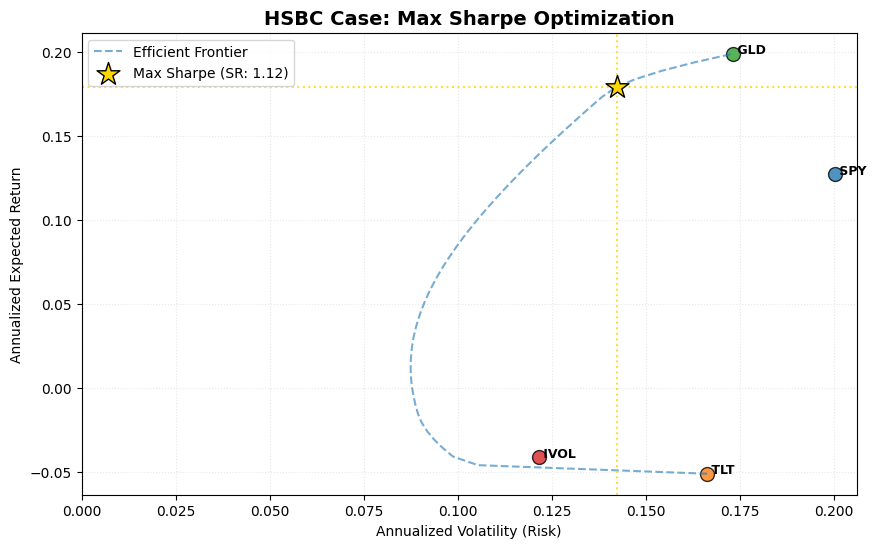

In [22]:
fig, weights = plot_efficient_frontier(mu, cv, basket, find_max_sharpe = True)
plt.show()


In [23]:
weights


SPY     2.735155e-01
TLT     5.809846e-17
GLD     7.264845e-01
IVOL    0.000000e+00
Name: Optimal weights, dtype: float64

# Black Litterman
Need additional expected mu, conviction 

In [28]:
views_dict = {
    "SPY": 0.3,
    "TLT": -0.1,
    "GLD": 0.3,
    "IVOL": 0.2
}

conf_dict = {
    "SPY": 0.3,
    "TLT": 0.5,
    "GLD": 0.8,
    "IVOL": 0.6
}
market_caps = get_market_caps(basket)
market_caps


SPY     6.812098e+11
TLT     4.435384e+10
GLD     1.818278e+11
IVOL    4.873620e+08
Name: Market_Cap, dtype: float64

In [ ]:
bl_mu = get_black_litterman(
    cov_matrix=cv,          # Your covariance matrix
    mcaps=market_caps,            # Your Series of market caps
    views_dict=views_dict,  # The {Ticker: Return} dict
    conf_dict=conf_dict,    # The {Ticker: Confidence} dict
    delta=3.0,              # Risk aversion
    tau=0.5                # Conviction of conviction
)

bl_mu


SPY     0.186409
TLT    -0.028155
GLD     0.249709
IVOL    0.136128
Name: BL Adjusted Returns, dtype: float64

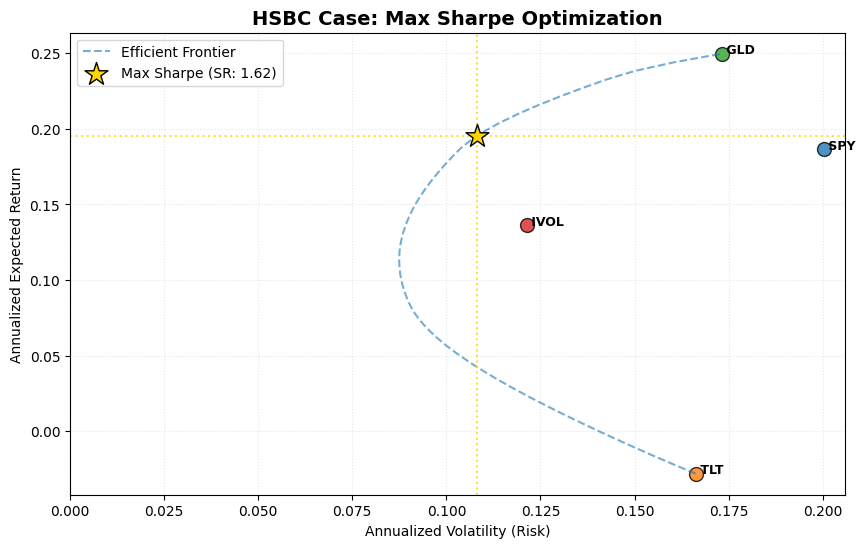

In [30]:
fig, weights = plot_efficient_frontier(bl_mu, cv, basket, find_max_sharpe = True)
plt.show()


In [31]:
weights


SPY     2.252032e-01
TLT     2.591243e-17
GLD     4.226325e-01
IVOL    3.521642e-01
Name: Optimal weights, dtype: float64